In [2]:
from pathlib import Path
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


## Injection

In [4]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [5]:
n = 50
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(20, 5000, n)
src_pos_array = np.geomspace(0.02, 0.99, n)
R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh
events['src_pos'] = src_pos_mesh

## Plot

In [6]:
SNR_at_1_Gpc = HLV_AGN.SNR(events)

In [7]:
general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = general_event_params['relative_mass']
frac_mass_diff = onp.asarray(np.abs(relative_mass - 1))

Text(0.5, 0.98, 'Contours = SNR / Gpc')

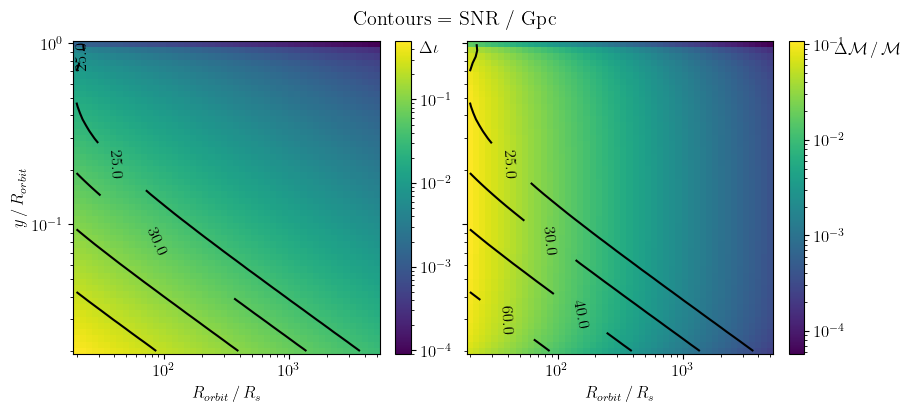

In [8]:
SNR_levels = [25, 30, 40, 60]

fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey='row', constrained_layout=True)

ax = axs[0]
im = ax.pcolormesh(R_orbit_array, src_pos_array, delta_iota,
                       norm=LogNorm()
                       )
cbar = fig.colorbar(im)
cbar.set_label(r'$\Delta\iota$', labelpad=-10, loc='top', rotation=0)
contour = ax.contour(R_orbit_array, src_pos_array, SNR_at_1_Gpc, 
                         levels=SNR_levels, colors='black')
ax.clabel(contour, fmt='%1.1f', colors='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$y\,/\,R_{orbit}$')
ax.set_xlabel(r'$R_{orbit}\,/\,R_s$')

ax = axs[1]
im = ax.pcolormesh(R_orbit_array, src_pos_array, frac_mass_diff,
                       norm=LogNorm()
                       )
cbar = fig.colorbar(im)
cbar.set_label(r'$\Delta\mathcal{M}\,/\,\mathcal{M}$', labelpad=40, loc='top', rotation=0)
contour = ax.contour(R_orbit_array, src_pos_array, SNR_at_1_Gpc, 
                         levels=SNR_levels, colors='black')
ax.clabel(contour, fmt='%1.1f', colors='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_{orbit}\,/\,R_s$')

fig.suptitle(r'Contours = SNR / Gpc')